# Project Goal: To conduct a comprehensive risk assessment and pricing analysis of a health insurance portfolio by identifying key risk drivers, quantifying their financial impact, and providing data-driven recommendations for reserve setting and premium pricing.

**Background and Motivation:** I've always been fascinated by how insurance companies mathematically price uncertainty. This project was my hands-on exploration of how data transforms into dollars—how claim distributions translate to premium calculations and reserve requirements.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import math 

# 1) Loading Dataset

I will be using the Medical Cost Personal Datasets from Kaggle. It is retrieved from, https://www.kaggle.com/datasets/mirichoi0218/insurance/data

In [4]:
df = pd.read_csv('insurance.csv')
print('\nData Preview:')
display(df.head())


Data Preview:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 2) Exploratory Data Analysis

In [5]:
print('\nInfo:')
pd.set_option('display.max_info_columns', 200)
print(df.info())
print('\nShape:')
print(df.shape)
df.describe(include='all')


Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

Shape:
(1338, 7)


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [6]:
s = pd.to_numeric(df['charges'], errors = 'coerce').dropna() 

print(len(s))

1338


# 3) Visualisations


In [7]:
def sturges_bins(n):
    return int(np.ceil(math.log(2*n) + 1))

In [8]:
def fd_bins(x):
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    h = 2 * iqr * (n ** (-1/3))
    return int(np.ceil((x.max() - x.min()) / h)) if h > 0 else 10

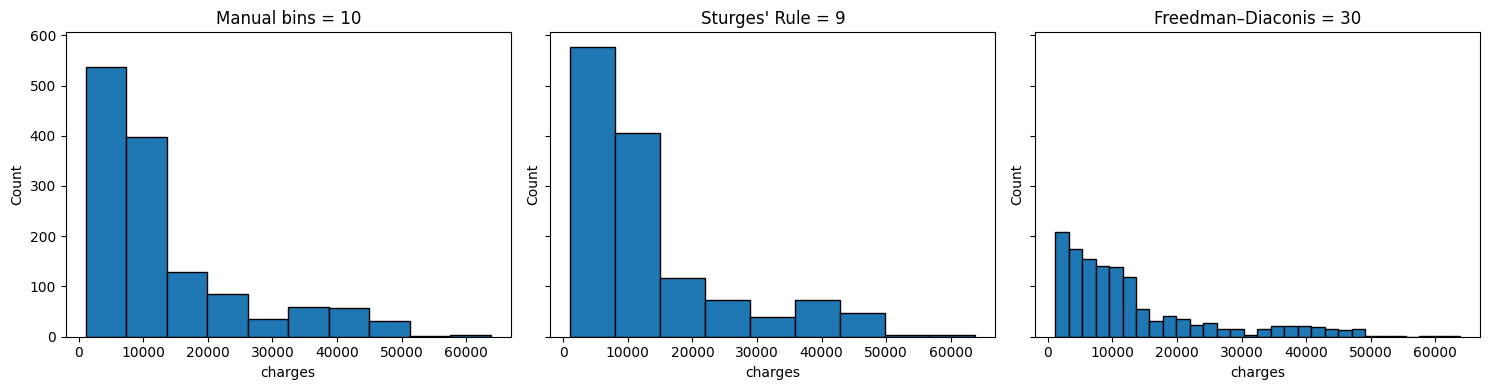

In [9]:
x = df['charges'].values
n = len(x)

bins_manual = 10 
bins_sturges = sturges_bins(n)
bins_fd = fd_bins(x)

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

axes[0].hist(x, bins=10, edgecolor='black')
axes[0].set_title(f"Manual bins = {bins_manual}")

axes[1].hist(x, bins=bins_sturges, edgecolor='black')
axes[1].set_title(f"Sturges' Rule = {bins_sturges}")

axes[2].hist(x, bins=bins_fd, edgecolor='black')
axes[2].set_title(f"Freedman–Diaconis = {bins_fd}")
for ax in axes:
    ax.set_xlabel("charges")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

The histogram show a right-skewed distribution, with most observation concentrated between 0 to 15000. There is a noticeable peak between 35000 to 45000. Beyond 50000, the frequency of charges drop sharply, indicating few very high cost cases. This explains the need for reserving in insurance companies, where they must set aside funds from premiums to cover future payments for those rare and expensive tail events.

Pros: Easy to interpret and widely understood. Directly show counts/frequencies in bins
Cons: Shape depends heavily on bin width/choice. Can look jagged or misleading if bins are poorly chosen

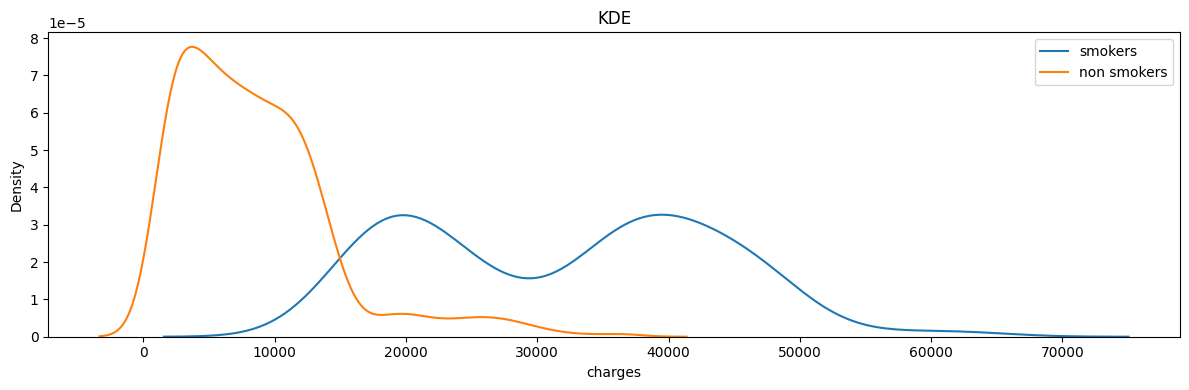

In [10]:
smokers = df.loc[df['smoker'] == "yes", 'charges']
nonsmokers = df.loc[df['smoker'] == "no", 'charges']

fig, ax = plt.subplots(figsize=(12,4))

sns.kdeplot(x=smokers, bw_adjust=1, ax=ax, label="smokers")
sns.kdeplot(x=nonsmokers, bw_adjust=1, ax=ax, label="non smokers")

ax.set_title("KDE")
ax.set_xlabel("charges")
ax.legend()

plt.tight_layout()
plt.show()

The KDE for smokers is more right-skewed than that for non-smokers, with a longer right tail extending towards higher insurance charges. This proves the pricing assumption where insurance companies must charge more for smokers, as the 'non-smokers' would be subsidising the 'smokers', resulting in a risk to the company's profit. 

Pro: Useful for highlighting overall shape and trends
Con: May show peaks or valleys that are not truly present in the data

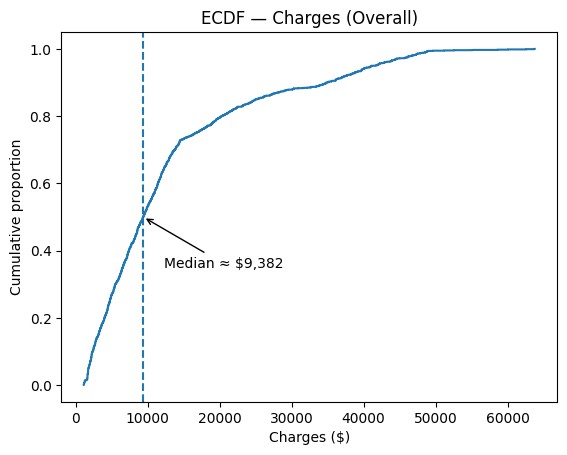

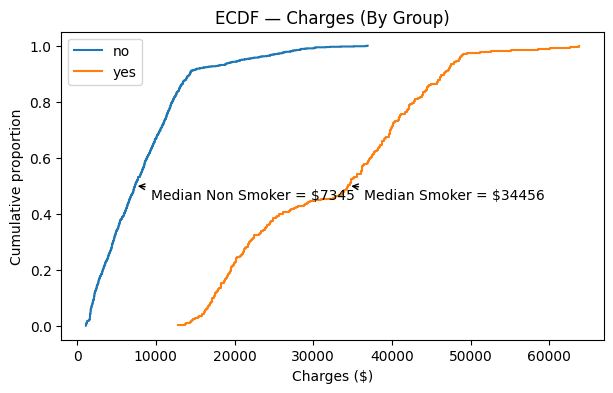

In [24]:
def ecdf(arr):
    arr = np.asarray(arr)
    x = np.sort(arr)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

# Overall ECDF
x_ecdf, y_ecdf = ecdf(df['charges'])

median = df['charges'].median()
median_y = (df['charges'] <= median).mean()

plt.axvline(median, linestyle='--')
plt.annotate(
    f"Median ≈ ${median:,.0f}",
    xy=(median, median_y),
    xytext=(median*1.3, median_y-0.15),
    arrowprops=dict(arrowstyle='->')
)

plt.step(x_ecdf, y_ecdf, where='post')
plt.title("ECDF — Charges (Overall)")
plt.xlabel("Charges ($)")
plt.ylabel("Cumulative proportion")
plt.show()

# ECDF by species
plt.figure(figsize=(7,4))
for sp, g in df.groupby('smoker'):
    xs, ys = ecdf(g['charges'].dropna())  
    label = "Smoker" if sp == "yes" else "Non Smoker"
    plt.step(xs, ys, where='post', label=sp)

for sp, g in df.groupby('smoker'):
    median = g['charges'].median()
    y_pos = (g['charges'] <= median).mean()
    label = "Smoker" if sp == "yes" else "Non Smoker"
    plt.annotate(
        f"Median {label} = ${median:.0f}",
        xy=(median, y_pos),
        xytext=(median+2000, y_pos-0.05),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )

plt.title("ECDF — Charges (By Group)")
plt.xlabel("Charges ($)")
plt.ylabel("Cumulative proportion")
plt.legend()
plt.show()

**Charges (Overall)**
50% of the charges are below 9382, which is the median claim amount. Most claims are between 0 to 50000, with a few extreme claims above 50000. The ECDF is steep at low values and flatten at high values which indicates a right skewed distribution where there are only a few number of very high claims. 

**Charges (By Group)**
50% of the charges are below 7345 for non smokers while 50% of the charges are below 34456 for smokers. This indicates that smokers generally have a higher charge than non smokers. 

Pro: Allows us to visualize the entire data distribution without needing to choose bin sizes or smoothing parameters. 
Con: It is a step function (increasing by \(1/n\) at each point), it can hide the underlying continuity of data and look sparse in regions with fewer data points.

/var/folders/l4/tx1qgyp969nbd89gd0vrls6h0000gn/T/ipykernel_1266/3273677994.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='bmi_category', y='charges', inner='box', ax=ax, palette='coolwarm')


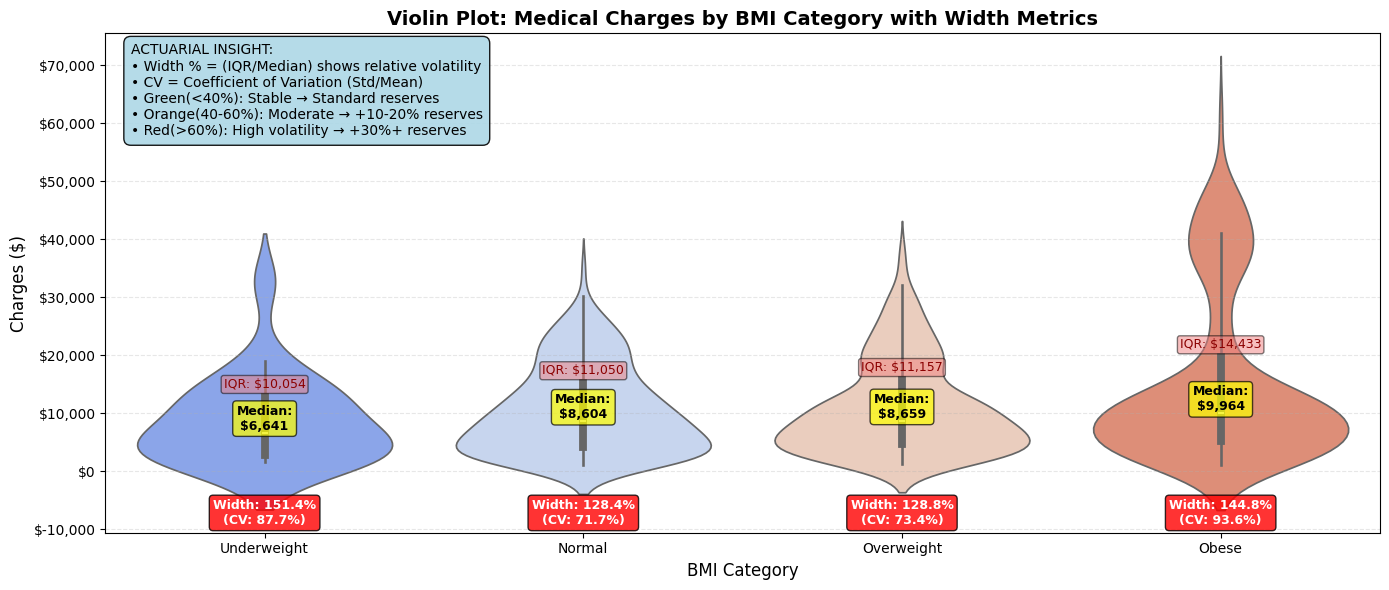

VIOLIN WIDTH/VOLATILITY ANALYSIS SUMMARY
             Median Charges      IQR Width % (IQR/Median)   CV %  \
bmi_category                                                       
Underweight          $6,641  $10,054               151.4%  87.7%   
Normal               $8,604  $11,050               128.4%  71.7%   
Overweight           $8,659  $11,157               128.8%  73.4%   
Obese                $9,964  $14,433               144.8%  93.6%   

             Volatility Rating Reserve Recommendation  
bmi_category                                           
Underweight               High            +30% Margin  
Normal                    High            +30% Margin  
Overweight                High            +30% Margin  
Obese                     High            +30% Margin  



In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

bins = [0, 18.5, 25, 30, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels)

# Create figure with adjusted size for annotations
fig, ax = plt.subplots(figsize=(14, 6))  # Wider to accommodate width annotations

# Calculate statistics
medians = df.groupby('bmi_category')['charges'].median()
q1 = df.groupby('bmi_category')['charges'].quantile(0.25)
q3 = df.groupby('bmi_category')['charges'].quantile(0.75)

# Calculate width/volatility metrics
cv = df.groupby('bmi_category')['charges'].std() / df.groupby('bmi_category')['charges'].mean() * 100
relative_iqr = ((q3 - q1) / medians) * 100

# Create violin plot
sns.violinplot(data=df, x='bmi_category', y='charges', inner='box', ax=ax, palette='coolwarm')

# Annotate with width metrics
for i, category in enumerate(labels):
    # Position annotations at different heights to avoid overlap
    y_pos_median = medians[category]
    y_pos_iqr = q3[category] + 1000  # Slightly above Q3
    y_pos_width = ax.get_ylim()[0] + 1000  # Near bottom of plot
    
    # Median annotation
    ax.text(i, y_pos_median, f'Median:\n${medians[category]:,.0f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # IQR annotation
    iqr_value = q3[category] - q1[category]
    ax.text(i, y_pos_iqr, f'IQR: ${iqr_value:,.0f}', 
            ha='center', va='bottom', fontsize=9, color='darkred',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="lightcoral", alpha=0.5))
    
    # WIDTH/VOLATILITY annotation (NEW)
    width_text = f"Width: {relative_iqr[category]:.1f}%\n(CV: {cv[category]:.1f}%)"
    width_color = 'red' if relative_iqr[category] > 60 else \
                  'orange' if relative_iqr[category] > 40 else 'green'
    
    ax.text(i, y_pos_width, width_text,
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color='white', bbox=dict(boxstyle="round,pad=0.3", 
                                    facecolor=width_color, alpha=0.8))

# Set titles and labels - CORRECTED: use 'ax' not 'axes[1]'
ax.set_title("Violin Plot: Medical Charges by BMI Category with Width Metrics", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("BMI Category", fontsize=12)
ax.set_ylabel("Charges ($)", fontsize=12)

# Add grid
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Format y-axis with dollar signs
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Enhanced actuarial insight with width interpretation
insight_text = ("ACTUARIAL INSIGHT:\n"
                "• Width % = (IQR/Median) shows relative volatility\n"
                "• CV = Coefficient of Variation (Std/Mean)\n"
                "• Green(<40%): Stable → Standard reserves\n"
                "• Orange(40-60%): Moderate → +10-20% reserves\n"
                "• Red(>60%): High volatility → +30%+ reserves")

ax.text(0.02, 0.98, insight_text, transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.9),
        verticalalignment='top')

plt.tight_layout()
plt.show()

# Print a summary table
print("=" * 60)
print("VIOLIN WIDTH/VOLATILITY ANALYSIS SUMMARY")
print("=" * 60)
summary_df = pd.DataFrame({
    'Median Charges': medians.map('${:,.0f}'.format),
    'IQR': (q3 - q1).map('${:,.0f}'.format),
    'Width % (IQR/Median)': relative_iqr.map('{:.1f}%'.format),
    'CV %': cv.map('{:.1f}%'.format),
    'Volatility Rating': ['Low' if x < 40 else 'Moderate' if x < 60 else 'High' 
                          for x in relative_iqr],
    'Reserve Recommendation': ['Standard' if x < 40 else '+15% Margin' if x < 60 else '+30% Margin'
                              for x in relative_iqr]
})

print(summary_df)
print("\n" + "=" * 60)

The group that is underweight has the widest violin plot while the group that has normal weight has the narrowest violin plot. This indicates that the underwight group has the highest volatility which means companies have to set aside high researves for them. 

Pro: Provides a complete view of the distribution.
Con: Harder to interpret than normal box plot.